# Application of GPCA to geographic clustering with respect to weather conditions

In this notebook, we use the Weather CORGIS Dataset to illustrate GPCA based on empirical covariance matrices. The dataset provides weekly measures of average temperate and wind speed recorded from March to January 2016 across the 50 U.S. states and the territory of Puerto Rico. From these measures, we construct two histograms for each state: one for temperature and one for wind speed. We then compute the 50 empirical covariances from these histograms. We show then show the projection of each state onto the two first GPCA components computed from the empirical covariance matrices. This corresponds to Figure 14 in [1]. We can clearly identify clusters of different weather behavior among the states.

[1] N. Vesseron, A. Le Brigant, E. Cazelles and T. Klein. On the Wasserstein Geodesic Principal Components Analysis of probability measures, *International Conference on Learning Representations (ICLR)*, 2026

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pca.bures_wasserstein_geodesic_pca import *
from tools.plot_2d import *

INFO: Using numpy backend


#### Load wind speed and temperature data

In [3]:
df = pd.read_csv('weather.csv')
unique_states = df['Station.State'].unique()
print('The states considered are :')
print(unique_states)

wind_by_state = df.groupby('Station.State')['Data.Wind.Speed'].apply(list)
temperature_by_state = df.groupby('Station.State')['Data.Temperature.Avg Temp'].apply(list)

The states considered are :
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'DE' 'Delaware' 'Florida' 'Georgia' 'Hawaii' 'Idaho'
 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky' 'Louisiana' 'Maine'
 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota' 'Mississippi'
 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire' 'New Jersey'
 'New Mexico' 'New York' 'North Carolina' 'North Dakota' 'Ohio' 'Oklahoma'
 'Oregon' 'Pennsylvania' 'Puerto Rico' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'VA' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


#### Construct empirical covariance matrices

In [4]:
covariances = {}

x_min, x_max = min(min(wind_by_state)), max(max(wind_by_state))
y_min, y_max = min(min(temperature_by_state)), max(max(temperature_by_state))

for state in unique_states:
    x_wind_speed = np.array(wind_by_state[state])
    y_temperature = np.array(temperature_by_state[state])
    
    x_histo, _ = np.histogram(x_wind_speed, range=(x_min,x_max), bins=500, density=True)
    y_histo, _ = np.histogram(y_temperature, range=(y_min,y_max), bins=500, density=True)
    
    cov_matrix = np.cov(x_histo, y_histo)       
    covariances[state] = cov_matrix

print(covariances)

{'Alabama': array([[ 0.0093746 , -0.00059061],
       [-0.00059061,  0.00265745]]), 'Alaska': array([[ 2.18123831e-03, -5.25555455e-05],
       [-5.25555455e-05,  3.52399475e-03]]), 'Arizona': array([[ 0.00963701, -0.00056543],
       [-0.00056543,  0.00180508]]), 'Arkansas': array([[ 0.01554028, -0.00054908],
       [-0.00054908,  0.00193641]]), 'California': array([[ 0.00450681, -0.00053599],
       [-0.00053599,  0.00243734]]), 'Colorado': array([[ 0.00948646, -0.00024305],
       [-0.00024305,  0.00131361]]), 'Connecticut': array([[ 1.53429828e-02, -3.95801722e-05],
       [-3.95801722e-05,  1.97534254e-03]]), 'DE': array([[ 0.02501077, -0.00038913],
       [-0.00038913,  0.00291344]]), 'Delaware': array([[ 0.02501077, -0.00038913],
       [-0.00038913,  0.00291344]]), 'Florida': array([[ 0.00489146, -0.0005758 ],
       [-0.0005758 ,  0.00315444]]), 'Georgia': array([[ 0.00763779, -0.00059187],
       [-0.00059187,  0.00222594]]), 'Hawaii': array([[ 0.00534372, -0.00059994],
     

#### Apply GPCA on the empirical covariance matrices

In [5]:
points_spd = np.stack([covariances[state] for state in unique_states])

res_pca = BuresWassersteinGPCA(2, sym_matrix_init=np.eye(2)).fit(points_spd)

#### Visualize the projection of each state onto the two first GPCA components

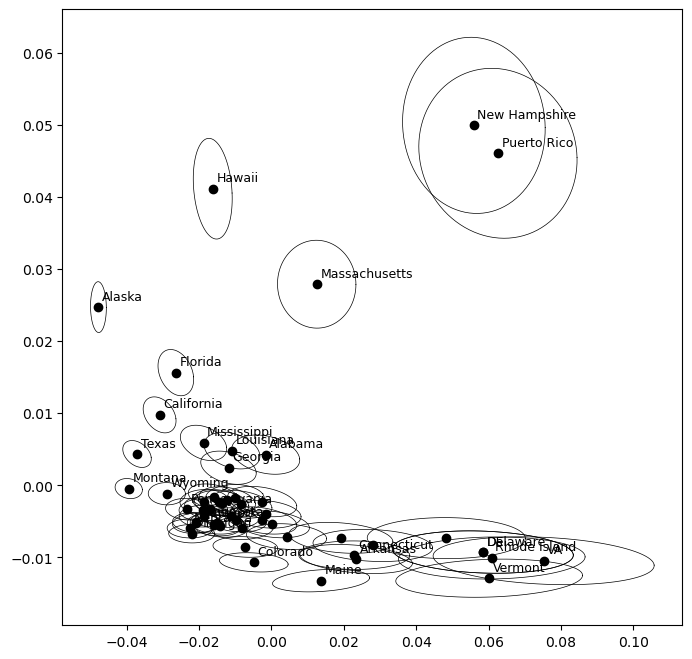

In [6]:
plt.figure(figsize=(8,8))
for index, t in enumerate(res_pca.times.T):
    plt.scatter(t[0], t[1], color='k')
    plot_spd_matrix_translated(points_spd[index], t, color='k', linewidth=0.5) 
    if (t[0] < -0.02 or t[0] > 0.05 or t[1] > 0 or t[1] < -0.009):
        plt.text(t[0] + 0.001, t[1] + 0.001, unique_states[index], fontsize=9)